In [1]:
#MOana specific
import os, subprocess
print("PID:", os.getpid())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("hostname:", subprocess.run(["hostname"], capture_output=True, text=True).stdout.strip())
print(subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).stdout)


PID: 2747
CUDA_VISIBLE_DEVICES: None
hostname: b9229902d877
GPU 0: NVIDIA TITAN X (Pascal) (UUID: GPU-3f2d65bc-b02a-fda5-51fc-72ed6e13beed)
GPU 1: NVIDIA TITAN X (Pascal) (UUID: GPU-d3a09050-15e1-11e6-e9ca-02fad034f13a)
GPU 2: NVIDIA TITAN X (Pascal) (UUID: GPU-445803e7-81b2-f9b2-fb68-27d1e934937a)
GPU 3: NVIDIA TITAN X (Pascal) (UUID: GPU-6044dc59-ec99-d562-5689-4099eb7024b0)



In [2]:

#MOANA ONLY
#os.environ["CUDA_VISIBLE_DEVICES"] = "1"
#check for errors
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


In [80]:
# Cell 0 — CONFIG
from pathlib import Path
import numpy as np
%load_ext autoreload
%autoreload 2
import sys, os
from dotenv import load_dotenv
# Find the repo root by walking up until we hit src/A_Config.py -- see
# AA_Cam_pose_estimate_batches.ipynb for why this is more robust than Path.cwd().parent.
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
print("project_root:", project_root)

#-----------------------------
load_dotenv(project_root / ".env")
case_name = "201_copper_01"
experiment = "render_test_2"
#Question = "Where is the first cat in this video?"
#----------------------

asset_name = f"{case_name}_{experiment}"
from A_Config import set_case
set_case(case_name, experiment)
#These neeed work
case_dir     = project_root / "Data" / case_name
source_dir   = case_dir     / "010_source"
query_dir    = case_dir     / "012_Gemini_outputs"
yolo_masks_dir = case_dir   / "015_YOLO" / experiment
#temp delete sub folder
frames_for_cam_poses = case_dir / "020_frames_for_cam_poses" 
frames_for_recon   = case_dir   / "020_frames_for_recon" / experiment 
VGGT_O_output_dir   = case_dir   /"035_VGGT_O_output"/experiment
predictions_path =  case_dir   /  VGGT_O_output_dir /"predictions.npz" 
CUT3R_output_dir    = case_dir   /"035_CUT3R_output" / experiment
ply_dir             =   VGGT_O_output_dir  /"ply"         
#temp - need to sort out a unified place? no visualisation is justfor me
reg_dir        = case_dir     / "030_Registrations"
csv_path_GPS = case_dir     / "000_GPS_Data" / "GPS_tags.csv"
csv_path_pose = reg_dir     /"camera_poses.csv"


FRAME_NAME_FMT = "{:04d}.jpg"

#TEMP
#This needs to be filed after user input decides on what to analyse
ppt_template = '03_Version_1'

# video loading
# Auto-find the video in 010_source
videos = list(source_dir.glob("*.mp4"))
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")

#reporting
from C_CSV_report import add_to_report
overview = {
    "Video_name"      : video_path.name, 
    "Title"      : f"{case_name}_{experiment}"
}
add_to_report(overview)
api_key = os.getenv("STREETVIEW_API_KEY")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
project_root: /workspaces/knuckles_drive
Case    : 201_copper_01
Video   : log_1081378_body-cam_v1.mp4


In [15]:
#FLAGS dict and 'producer dict
flags = {
    "VID_TO_TEXT": True,
    "TRACKING": True,
    "FRAME_SELECTION": True,
    "RECON_CAM_POSES": True,
    "RECON_3D": True,
    "CUT3R_RECON": True,
    "MEGA_SAM_RECON": True,
    "VGGT_RECON": True,
    "VGGT_O_RECON": True,
    "MULTI_PART_RECON": False,
    "GOOGLE_MAP": True,
    "PROJECTION_MAP": True,
    "MAKE_MOVIE": True,
    "MAKE_MOVIE_CUTS" : True,
    "MASK_OVERLAYS": True ,
    "PHYSICS_OVERLAYS" : True,
    "MULTICAM" : True
}
MENU_KEYS = {"RECON_CAM_POSES", "RECON_3D", "CUT3R_RECON", "MEGA_SAM_RECON",
             "VGGT_RECON", "VGGT_O_RECON", "MULTI_PART_RECON",
             "GOOGLE_MAP", "PROJECTION_MAP", "MASK_OVERLAYS", "MULTICAM"}
producer_flags = {k: v for k, v in flags.items() if k in MENU_KEYS}

In [68]:
#START AND END CALCULATORS
start_3D_recon = 4889
end_3D_recon = 5440

print("start 3d", start_3D_recon)
print("end 3d" ,end_3D_recon)

movie_start = start_3D_recon - (5* 30) #this needs to be made auto
movie_end = end_3D_recon + (5*30)

#find the limits of vggt
capacity = 100
recon_dur = end_3D_recon - start_3D_recon
recon_interframe_interval =   (recon_dur+capacity-1) // capacity
print("interval" , recon_interframe_interval)

start 3d 4889
end 3d 5440
interval 6


In [69]:
#FRAMES FOR RECON SELECTION - Frame selection to make the recon

if flags["RECON_3D"] == True and flags["FRAME_SELECTION"] == True:
    # Parameters
    fps = 30.07
    interval     = recon_interframe_interval/fps      # seconds between samples - expressed as frames to skip, per second(frame rate)
    window       = 15     # search window for sharpness
    min_sharp    = 0.0    # raise this after inspecting selection_log.json
   
    import sys
    sys.path.insert(0, str(project_root / "src"))

    from B_video_processing import image_sequencer

    results = image_sequencer(
        #video_path    = str(video_path),
        video_path = str(video_path),
        output_dir    = str(frames_for_recon),
        #res           = res,
        interval_sec  = interval,
        search_window = window,
        min_sharpness = min_sharp,
        start_frame  = start_3D_recon, 
        end_frame    = end_3D_recon 

    )

    print(f"\n{len(results)} frames written to {frames_for_recon}")
else:
    print("Cell disabled")

Window  : clamped from ±15 to ±3 (half interval)
Video   : log_1081378_body-cam_v1.mp4
          30 fps · 21072 frames · 703.1s
Range   : frames 4889-5440 (551 frames)
Sampling: every 6 frames (0.19953441968739608s) → 92 candidates
Window  : ±3 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 551/551 [00:00<00:00, 688.86fr/s]


Selected: 92 frames  (30 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 551/551 [00:00<00:00, 608.67fr/s]

Log     : /workspaces/knuckles_drive/Data/201_copper_01/020_frames_for_recon/render_test_3/selection_log.json
Sharpness (at 25% res): min 471 · mean 937 · max 1427

2 frames written to /workspaces/knuckles_drive/Data/201_copper_01/020_frames_for_recon/render_test_3


In [70]:
#VGGT OMEGA 

#Decide which tool to use - based on #of frames
#if  end_3D_recon - start_3D_recon < 150:
MULTI_PART_RECON = False

# Cell — VGGT-Omega reconstruction across multiple GPUs
if flags["VGGT_O_RECON"] == True and flags["RECON_3D"] == True:
    if  flags["MULTI_PART_RECON"] == False:
        import gc, torch
        gc.collect()
        torch.cuda.empty_cache()

        import sys
        sys.path.insert(0, str(project_root / "src"))

        from run_models.E_VGGT_O_shards import run_vggt_omega_shards

        recon_out = case_dir / "035_VGGT_O_output" / experiment

        run_vggt_omega_shards(
            image_dir              = str(frames_for_recon),
            output_dir             = str(recon_out),
            checkpoint_path        = str(project_root / "Models" / "vggt-omega" / "checkpoints" / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"),
            vggt_omega_shards_dir  = str(project_root / "Models" / "vggt-omega-shards"),
            devices                = ["cuda:0", "cuda:1", "cuda:2", "cuda:3"],
            image_resolution       = 512,
            conf_thres             = 20.0,
            max_points             = 0,
            show_cam               = True,
        )



#VGGT OMEGA (sharded) BATCH
# Cell — VGGT-Omega reconstruction across multiple GPUs - run a long sequence thorugh the batch processor.
#it sends in batches of 100 with an overlap of 1 frame for later alignment
if flags["VGGT_O_RECON"] == True and flags["RECON_3D"] == True and flags["MULTI_PART_RECON"] == True:
    import gc, torch
    gc.collect()
    torch.cuda.empty_cache()

    import sys
    sys.path.insert(0, str(project_root / "src"))


    from run_models.E_VGGT_O_shards import run_vggt_omega_shards_batched

    recon_out = case_dir / "035_VGGT_O_output" / experiment

    run_vggt_omega_shards_batched(
        image_dir              = str(frames_for_recon),
        output_dir             = str(recon_out),
        checkpoint_path        = str(project_root / "Models" / "vggt-omega" / "checkpoints" / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"),
        vggt_omega_shards_dir  = str(project_root / "Models" / "vggt-omega-shards"),
        devices                = ["cuda:0", "cuda:1", "cuda:2", "cuda:3"],
        image_resolution       = 512,
        conf_thres             = 20.0,
        max_points             = 0,
        show_cam               = True,
    )


        

    

91 frames across 4 GPUs: ['cuda:0', 'cuda:1', 'cuda:2', 'cuda:3']
Running aggregator on 91 frames at 512px across 4 GPUs...


(viser) Connection closed (0, 0 total)

(viser) Connection closed (0, 0 total)

Aggregator done in 1386.7s
Predicting camera poses...
Camera head done in 0.2s
Predicting depth maps...
Depth head done in 1.8s
Saved: /workspaces/knuckles_drive/Data/201_copper_01/035_VGGT_O_output/render_test_3/predictions.npz
Saved: /workspaces/knuckles_drive/Data/201_copper_01/035_VGGT_O_output/render_test_3/predictions.glb


In [81]:
#LOAD VGGT_O recon for further processing
if flags["MULTI_PART_RECON"] == False:
    from F_post_recon_processing import Reconstruction
    recon = Reconstruction.load(frames_for_recon, predictions_path, FRAME_NAME_FMT)
else:
    print("Cell Disabled")
print("reco loaded from ", predictions_path)

reco loaded from  /workspaces/knuckles_drive/Data/201_copper_01/035_VGGT_O_output/render_test_2/predictions.npz


In [88]:
conf     = recon.preds["depth_conf"].cpu().numpy()
print(conf.min(), conf.max())
print(conf.shape)
print(np.percentile(conf, [5, 25, 50, 75, 95]))

1.0 12.802336
(99, 384, 688)
[1.00020432 1.07272014 1.2879023  1.64543915 2.38451304]


In [89]:
#CAMERA TRANSFORMS - single recon at the moment
import torch
#1m up
ext_30 = recon.preds["extrinsic"][30].clone()
#ext[1, 3] += 1/16   # lift camera 1m (1/16 scale)

#10m up BEV
ext9 = recon.preds["extrinsic"][9]
Rx = torch.tensor([[1., 0., 0.],
                   [0., 0., -1.],
                   [0., 1., 0.]], dtype=ext9.dtype, device=ext9.device)

ext = Rx @ ext9        # pitch 90° down, camera stays where cam 9 was
ext[2, 3] += 20/16     # lift 10m (up is -z now that the view axis points down)
ext[1, 3] += 5/16      # forward 5m along cam 9's original heading

In [ ]:
flags["PROJECTION_MAP"] = True
if flags["PROJECTION_MAP"] == True:
    #2D projection mapping of subject to a selected view
    from F_post_recon_processing import Reconstruction
    from P_projection_mapping import projection_mapping_sequence
    from B_video_processing import available_frames
    
    #Use this to project every frame in the recon
    extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)
    print(extra_indices)
    
    
    if MULTI_PART_RECON == True:
      recon = recons
      point_cloud_xforms = point_cloud_xforms
    else: 
      recon = recon
      point_cloud_xforms = None
    subject_positions = projection_mapping_sequence(
        
        recon         = recon,
        #main_idx      = 4189,
        #extra_indices = range (4189,5440),
          #other syntax  [400,4027, 4052, 4065],
        extra_indices = extra_indices, # for composite (double [[]])
        #extra_indices = [extra_indices] # for composite (double [[]])
        #masks_dir     = str(yolo_masks_dir),
        #point_cloud_xforms = point_cloud_xforms

        new_view = ext_30 ,
        
        confidence_threshold = 10
       
       )
else:
    print("Cell disabled")

[4889, 4895, 4901, 4907, 4914, 4919, 4925, 4932, 4937, 4943, 4950, 4955, 4960, 4970, 4973, 4979, 4988, 4990, 4994, 5003, 5009, 5015, 5021, 5030, 5035, 5036, 5042, 5053, 5057, 5063, 5069, 5073, 5084, 5093, 5099, 5105, 5109, 5117, 5123, 5129, 5135, 5141, 5145, 5153, 5157, 5165, 5171, 5177, 5180, 5186, 5195, 5201, 5207, 5213, 5219, 5225, 5232, 5237, 5243, 5248, 5255, 5261, 5268, 5270, 5279, 5285, 5294, 5297, 5303, 5309, 5315, 5321, 5330, 5333, 5339, 5345, 5351, 5357, 5363, 5369, 5375, 5378, 5387, 5393, 5399, 5405, 5413, 5417, 5423, 5432, 5435]
[4889]
tensor(2.7396, device='cuda:0')
tensor(2.9299, device='cuda:0')
tensor(2.8462, device='cuda:0')
tensor(2.9222, device='cuda:0')
[4895]
tensor(2.8379, device='cuda:0')
tensor(2.9067, device='cuda:0')
tensor(2.9766, device='cuda:0')
tensor(2.9144, device='cuda:0')
[4901]
tensor(2.9377, device='cuda:0')
tensor(2.9532, device='cuda:0')
tensor(2.9689, device='cuda:0')
tensor(2.9377, device='cuda:0')
[4907]
tensor(2.7698, device='cuda:0')
tensor(2.

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [74]:
print(ext_30
      )

tensor([[ 0.8793, -0.4685, -0.0856, -0.0703],
        [ 0.4744,  0.8774,  0.0716, -0.0252],
        [ 0.0416, -0.1036,  0.9938, -0.0709]], device='cuda:0')


In [46]:
#processes spatial information about the recon and the cubject  - for report and generates the data needed to map the subject
#Takes the lat and long to do mapping
#Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in
MULTI_PART_RECON = False
ext = recon.preds["extrinsic"][30].clone()
ext = recon.preds["extrinsic"][0].clone()

if MULTI_PART_RECON == False:
        from Q_subject_analysis import subject_to_metric_and_gps_space
        from G_transforms_alignments import  recon_to_recon_transform
        #MAKE PLYS of VGGT__O
        #turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
       #n.b it translates to the beginning of the camera track solve, then re-translates to the recon cam 0 space. 
       
        _ = recon.VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" , 
                                             conf_threshold=1.1, 
                                             R=ext[:,0:3], 
                                             t=ext[:,3], 
                                             s=1)
        
        print(predictions_path)
else:
        print("Cell disabled")


/workspaces/knuckles_drive/Data/201_copper_01/035_VGGT_O_output/render_test_3/predictions.npz


(384, 688)


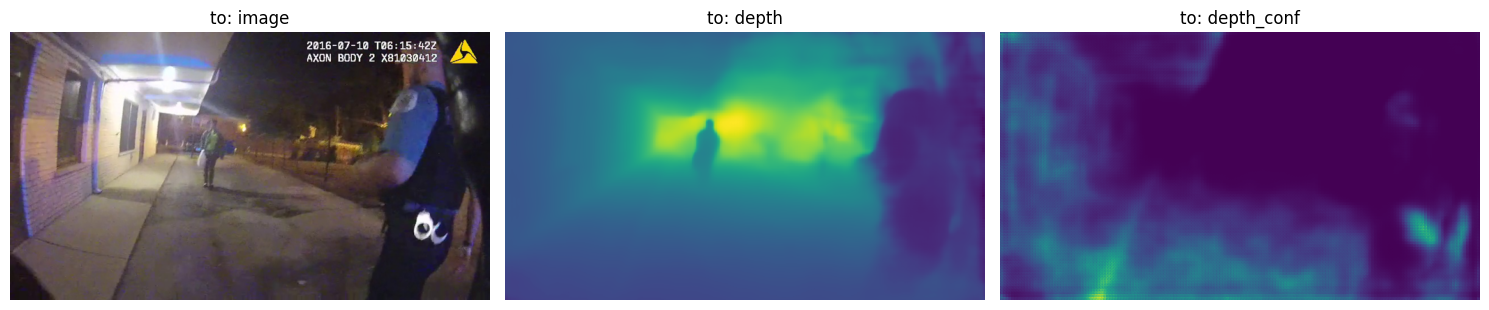

In [97]:
#QUICK LOOK AT DEPTH MAPS
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

index = 1

img    = recon.preds["images"][index].permute(1, 2, 0).cpu().numpy()
depth    = recon.preds["depth"][index].cpu().numpy()
conf     = recon.preds["depth_conf"][index].cpu().numpy()
print(depth.shape)
# PowerNorm with gamma<1 stretches the low end (near) of the colour ramp and
# compresses the high end (far) -- but unlike a vmax clip, every far pixel still
# gets its own distinct colour, just packed into a smaller share of the ramp.
depth_norm = mcolors.PowerNorm(gamma=0.5, vmin=depth.min(), vmax=depth.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 8))
for ax, im, title in zip(
    axes.ravel(),
    [img, depth, conf],
    ["to: image", "to: depth", "to: depth_conf", "from: image", "from: depth", "from: depth_conf"],
):
    if im is depth:
        ax.imshow(im, cmap="viridis", norm=depth_norm)
    else:
        ax.imshow(im, cmap=None if im.ndim == 3 else "viridis")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# Cell — PLY visualisation

    
import importlib, sys
sys.path.insert(0, str(project_root / "src"))


from Thr3D.F_cut3r_vis import visualise_cut3r
visualisation_dir = case_dir   /  "035_VGGT_O_output"/"render_test_3"
print(visualisation_dir)
#visualisation_dir = case_dir   /  CUT3R_output_dir
visualise_cut3r(visualisation_dir)

/workspaces/knuckles_drive/Data/201_copper_01/035_VGGT_O_output/render_test_3
Found 91 PLY files


╭────── viser (listening *:8086) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8086   │
│   Websocket │ ws://localhost:8086     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Connection opened (0, 1 total), 20 persistent messages

In [9]:
# Cell — PLY visualisation

    
import importlib, sys
sys.path.insert(0, str(project_root / "src"))


from Thr3D.F_cut3r_vis import visualise_cut3r
visualisation_dir = case_dir   /  VGGT_O_output_dir
print(visualisation_dir)
#visualisation_dir = case_dir   /  CUT3R_output_dir
visualise_cut3r(visualisation_dir)


/workspaces/knuckles_drive/Data/201_copper_01/035_VGGT_O_output/render_test_3
Found 91 PLY files


╭────── viser (listening *:8081) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8081   │
│   Websocket │ ws://localhost:8081     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Connection opened (0, 1 total), 20 persistent messages

(viser) Connection closed (0, 0 total)

/tmp/ipykernel_2747/1311942921.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


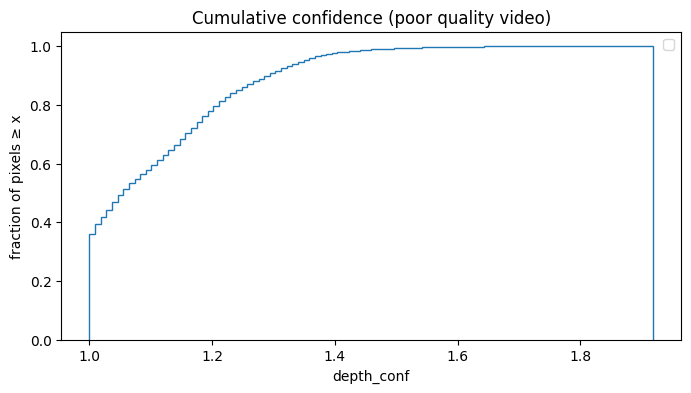

/tmp/ipykernel_2747/1311942921.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


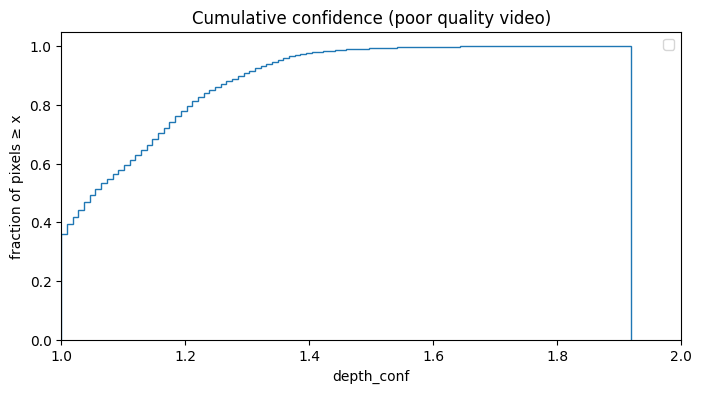

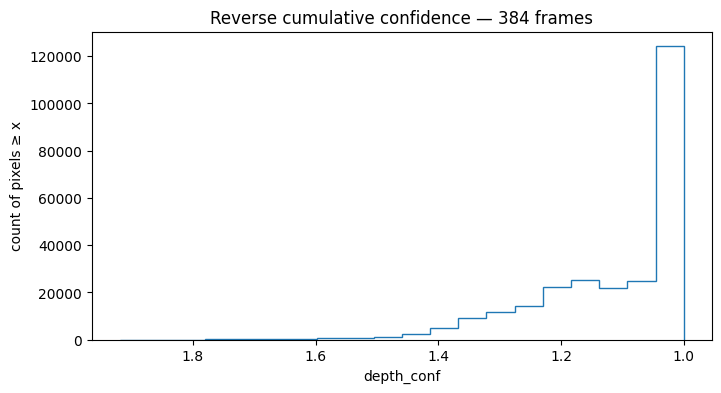

In [99]:
plt.figure(figsize=(8, 4))
plt.hist(conf.ravel(), bins=100, cumulative=1, density=True, histtype="step")
#plt.gca().invert_xaxis()
plt.xlabel("depth_conf")
plt.ylabel("fraction of pixels ≥ x")

plt.legend()
plt.title(f"Cumulative confidence (poor quality video)")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(conf.ravel(), bins=100, cumulative=1, density=True, histtype="step")
#plt.gca().invert_xaxis()
plt.xlabel("depth_conf")
plt.ylabel("fraction of pixels ≥ x")

plt.legend()
plt.title(f"Cumulative confidence (poor quality video)")
plt.xlim(1, 2)

plt.show()

conf_low = conf[(conf >= 1) & (conf <= 3)]

plt.figure(figsize=(8, 4))
plt.hist(conf_low.ravel(), bins=20, cumulative=0, density=False, histtype="step")
plt.gca().invert_xaxis()
plt.xlabel("depth_conf")
plt.ylabel("count of pixels ≥ x")

plt.title(f"Reverse cumulative confidence — {conf.shape[0]} frames")
plt.show()


In [100]:
#BEV projection mapping of subject to a selected view
from P_projection_mapping import projection_mapping_sequence, BEV_tile_render_PM
from B_video_processing import available_frames

#Use this to project every frame in the recon
extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)
#extra_indices = [23]
print(extra_indices)
recon = recon
BEV, new_view, ortho_params = BEV_tile_render_PM (recon, 
                     extra_indices, 
                     masks_dir=None, 
                     splat_radius=1,
                   confidence_threshold=1.1, 
                   margin_frac=0.05)  


[2442, 2480, 2543, 2590, 2641, 2697, 2732, 2794, 2845, 2896, 2951, 3000, 3049, 3100, 3142, 3202, 3251, 3316, 3355, 3399, 3457, 3508, 3559, 3597, 3661, 3723, 3752, 3812, 3865, 3919, 3967, 4018, 4069, 4120, 4171, 4222, 4265, 4312, 4387, 4434, 4466, 4528, 4577, 4630, 4681, 4725, 4770, 4834, 4885, 4936, 4987, 5036, 5101, 5140, 5202, 5248, 5294, 5334, 5381, 5461, 5500, 5548, 5602, 5650, 5701, 5758, 5803, 5844, 5897, 5968, 5996, 6058, 6094, 6169, 6198, 6274, 6313, 6376, 6415, 6478, 6509, 6573, 6619, 6670, 6716, 6784, 6837, 6874, 6927, 6965, 7035, 7078, 7129, 7170, 7231, 7279, 7336, 7392, 7438]


[2442, 2480, 2543, 2590, 2641, 2697, 2732, 2794, 2845, 2896, 2951, 3000, 3049, 3100, 3142, 3202, 3251, 3316, 3355, 3399, 3457, 3508, 3559, 3597, 3661, 3723, 3752, 3812, 3865, 3919, 3967, 4018, 4069, 4120, 4171, 4222, 4265, 4312, 4387, 4434, 4466, 4528, 4577, 4630, 4681, 4725, 4770, 4834, 4885, 4936, 4987, 5036, 5101, 5140, 5202, 5248, 5294, 5334, 5381, 5461, 5500, 5548, 5602, 5650, 5701, 5758, 5803, 5844, 5897, 5968, 5996, 6058, 6094, 6169, 6198, 6274, 6313, 6376, 6415, 6478, 6509, 6573, 6619, 6670, 6716, 6784, 6837, 6874, 6927, 6965, 7035, 7078, 7129, 7170, 7231, 7279, 7336, 7392, 7438]
tensor(2.7513, device='cuda:0')
tensor(2.7019, device='cuda:0')
tensor(2.7695, device='cuda:0')
tensor(2.8691, device='cuda:0')
tensor(2.7997, device='cuda:0')
tensor(2.8300, device='cuda:0')
tensor(2.7772, device='cuda:0')
tensor(2.9070, device='cuda:0')
tensor(2.7928, device='cuda:0')
tensor(2.7544, device='cuda:0')
tensor(2.8147, device='cuda:0')
tensor(2.8376, device='cuda:0')
tensor(2.8378, device

In [77]:
#render projection of 3D points clouds
from U_rendering import basic_point_cloud_render
#double way to get vggt and cut3r
if flags["VGGT_O_RECON"] ==True:
    visualisation_dir = case_dir   /  VGGT_O_output_dir 
    model = "VGGT_O"
   

    ply_dir = visualisation_dir / "ply"
    print(ply_dir)
    basic_point_cloud_render(
        ply_dir, model    )
    # report metric name = render name, one row per output asset (path relative to
    


/workspaces/knuckles_drive/Data/201_copper_01/035_VGGT_O_output/render_test_3/ply
/workspaces/knuckles_drive/Data/201_copper_01/090_assets/PC_render_frames_VGGT_O


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [7]:
#4D viewer
if flags["VGGT_O_RECON"] ==True:
     ply_dir = VGGT_O_output_dir  /"ply"  
from U_rendering import view_ply_sequence_with_scenepic
FourD =  view_ply_sequence_with_scenepic(
    ply_dir , 
    point_size=0.01, 
    pattern="*.ply")

python: can't open file '/workspaces/knuckles_drive/src/U_scenepic_o3d_worker.py': [Errno 2] No such file or directory
ERROR conda.cli.main_run:execute(125): `conda run python /workspaces/knuckles_drive/src/U_scenepic_o3d_worker.py --ply_dir /workspaces/knuckles_drive/Data/201_copper_01/035_VGGT_O_output/render_test_3/ply --output_html /workspaces/knuckles_drive/Data/201_copper_01/090_assets/201_copper_01_render_test_3_4d.html --point_size 0.01 --pattern *.ply` failed. (See above for error)


CalledProcessError: Command '['conda', 'run', '--no-capture-output', '-n', 'open_3D_env', 'python', '/workspaces/knuckles_drive/src/U_scenepic_o3d_worker.py', '--ply_dir', '/workspaces/knuckles_drive/Data/201_copper_01/035_VGGT_O_output/render_test_3/ply', '--output_html', '/workspaces/knuckles_drive/Data/201_copper_01/090_assets/201_copper_01_render_test_3_4d.html', '--point_size', '0.01', '--pattern', '*.ply']' returned non-zero exit status 2.